<a href="https://colab.research.google.com/github/Lovie-Tonimba/semester4-DataMining/blob/main/tugasDatasetIrisJobsheet11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [4]:
features = df.columns.tolist()
X = df[features]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

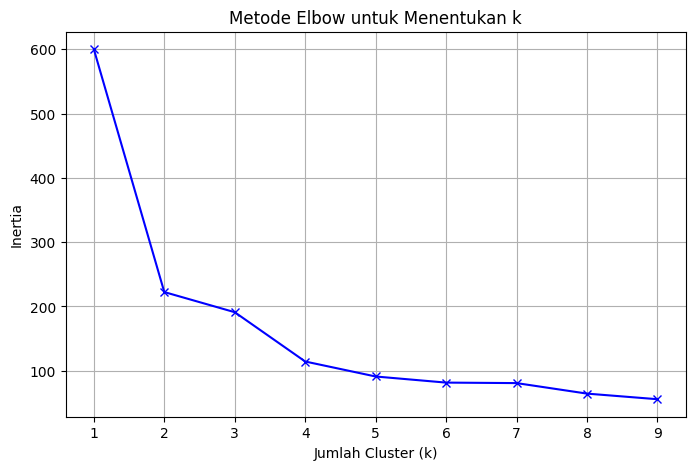

In [6]:
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot hasil elbow
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan k')
plt.grid(True)
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nData Setelah di-Clustering:")
print(df.head())


Data Setelah di-Clustering:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


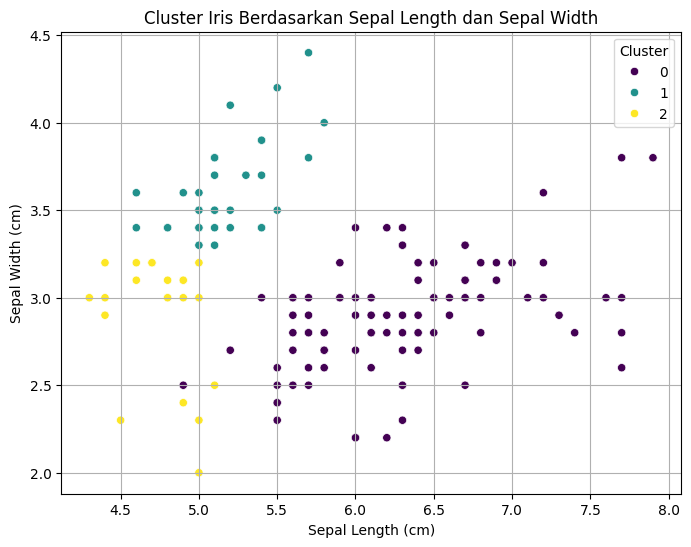

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['sepal length (cm)'], y=df['sepal width (cm)'], hue=df['Cluster'], palette='viridis')
plt.title('Cluster Iris Berdasarkan Sepal Length dan Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.grid(True)
plt.show()


Silhouette Score: 0.480
Inertia (k=3): 191.025


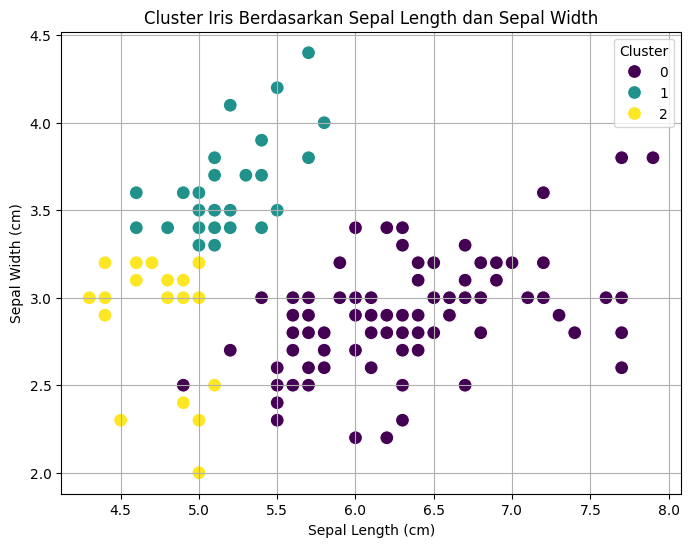

In [9]:
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette Score: {silhouette_avg:.3f}")
print(f"Inertia (k=3): {kmeans.inertia_:.3f}")

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['sepal length (cm)'],
    y=df['sepal width (cm)'],
    hue=df['Cluster'],
    palette='viridis',
    s=100
)
plt.title('Cluster Iris Berdasarkan Sepal Length dan Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [10]:
df['Target Asli'] = iris.target
df['Nama Spesies'] = [iris.target_names[i] for i in iris.target]

In [11]:
tabel_perbandingan = pd.crosstab(df['Cluster'], df['Nama Spesies'])
print("Tabel Perbandingan:")
print(tabel_perbandingan)

Tabel Perbandingan:
Nama Spesies  setosa  versicolor  virginica
Cluster                                    
0                  0          46         50
1                 33           0          0
2                 17           4          0


In [144]:
from sklearn.cluster import DBSCAN
# menggunakan data yang sudah distandardisasi (X_scaled) dari langkah sebelumnya
dbscan = DBSCAN(eps=0.6, min_samples=4)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

In [145]:
# kelompok yang terbentuk dan jumlah anggotanya
print("Jumlah data di masing-masing klaster DBSCAN:")
print(df['Cluster_DBSCAN'].value_counts())

Jumlah data di masing-masing klaster DBSCAN:
Cluster_DBSCAN
 2    82
 0    46
-1    19
 1     3
Name: count, dtype: int64


In [146]:
# Tabel Perbandingan
print("\nTabel Perbandingan DBSCAN:")
tabel_dbscan = pd.crosstab(df['Cluster_DBSCAN'], df['Nama Spesies'])
print(tabel_dbscan)


Tabel Perbandingan DBSCAN:
Nama Spesies    setosa  versicolor  virginica
Cluster_DBSCAN                               
-1                   1           7         11
 0                  46           0          0
 1                   3           0          0
 2                   0          43         39


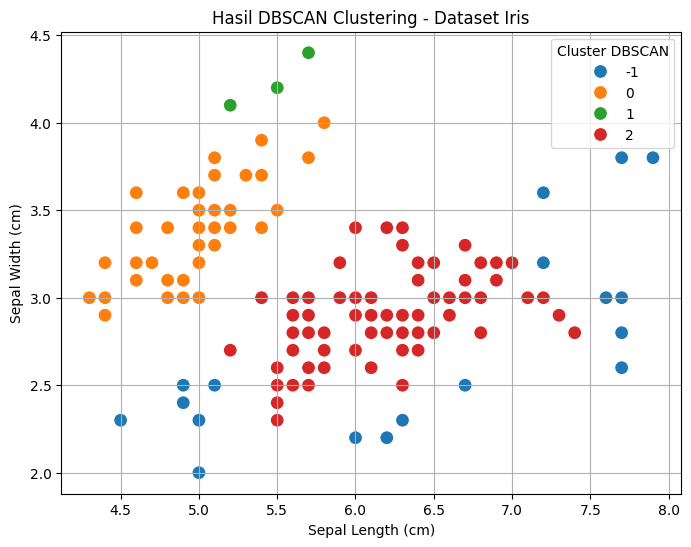

In [147]:
# visualisasi hasil DBSCAN menggunakan Sepal Length dan Sepal Width
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['sepal length (cm)'],
    y=df['sepal width (cm)'],
    hue=df['Cluster_DBSCAN'],
    palette='tab10',
    s=100
)

plt.title('Hasil DBSCAN Clustering - Dataset Iris')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Cluster DBSCAN')
plt.grid(True)
plt.show()

Tabel Perbandingan Agglomerative Clustering:
Nama Spesies  setosa  versicolor  virginica
Cluster_Agg                                
0                  0          23         48
1                 49           0          0
2                  1          27          2


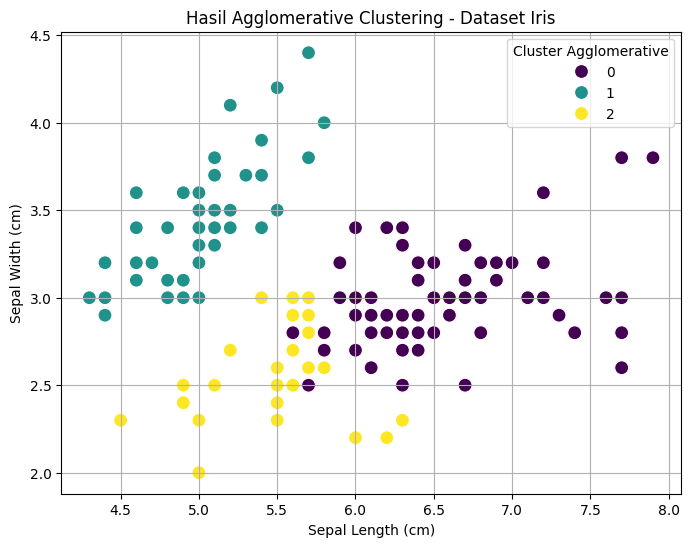

In [150]:
# Menggunakan Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clust = AgglomerativeClustering(n_clusters=3)
df['Cluster_Agg'] = agg_clust.fit_predict(X_scaled)

print("Tabel Perbandingan Agglomerative Clustering:")
tabel_agg = pd.crosstab(df['Cluster_Agg'], df['Nama Spesies'])
print(tabel_agg)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['sepal length (cm)'],
    y=df['sepal width (cm)'],
    hue=df['Cluster_Agg'],
    palette='viridis',
    s=100
)

plt.title('Hasil Agglomerative Clustering - Dataset Iris')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Cluster Agglomerative')
plt.grid(True)
plt.show()